In [1]:
#Import necessary libraries for data download
import pandas as pd
# Hugging Face datasets library
from datasets import load_dataset

c:\Users\Harijith\anaconda3\envs\emotion_nlp\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### DOWNLOAD DATASET

In [2]:
dataset = load_dataset("dair-ai/emotion")

# Display dataset information
print(dataset)

DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 16000
    })
    validation: Dataset({
        features: ['text', 'label'],
        num_rows: 2000
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 2000
    })
})


In [3]:
# ============================================
# VIEW SAMPLE DATA
# ============================================

# Print first training sample
print(dataset["train"][0])

{'text': 'i didnt feel humiliated', 'label': 0}


In [4]:
# ============================================
# CONVERT DATASETS TO PANDAS DATAFRAMES
# ============================================

train_df = dataset["train"].to_pandas()

val_df = dataset["validation"].to_pandas()

test_df = dataset["test"].to_pandas()


# Display first 5 rows
print(train_df.head())

                                                text  label
0                            i didnt feel humiliated      0
1  i can go from feeling so hopeless to so damned...      0
2   im grabbing a minute to post i feel greedy wrong      3
3  i am ever feeling nostalgic about the fireplac...      2
4                               i am feeling grouchy      3


In [5]:
# ============================================
# LABEL MAPPING
# ============================================

# Emotion label dictionary

label_map = {
    0: "sadness",
    1: "joy",
    2: "love",
    3: "anger",
    4: "fear",
    5: "surprise"
}

print(label_map)

{0: 'sadness', 1: 'joy', 2: 'love', 3: 'anger', 4: 'fear', 5: 'surprise'}


In [6]:
# ============================================
# CONVERT LABEL IDs TO EMOTION NAMES
# ============================================
# Create new emotion column

train_df["emotion"] = train_df["label"].map(label_map)
val_df["emotion"] = val_df["label"].map(label_map)
test_df["emotion"] = test_df["label"].map(label_map)

# Display updated dataframe
print(train_df.head())

                                                text  label  emotion
0                            i didnt feel humiliated      0  sadness
1  i can go from feeling so hopeless to so damned...      0  sadness
2   im grabbing a minute to post i feel greedy wrong      3    anger
3  i am ever feeling nostalgic about the fireplac...      2     love
4                               i am feeling grouchy      3    anger


In [7]:
# ============================================
# CHECK DATASET SHAPES
# ============================================
print("Training Data Shape:", train_df.shape)
print("Validation Data Shape:", val_df.shape)
print("Test Data Shape:", test_df.shape)

Training Data Shape: (16000, 3)
Validation Data Shape: (2000, 3)
Test Data Shape: (2000, 3)


In [8]:
#Checking emotion class distribution
print(train_df["emotion"].value_counts())

emotion
joy         5362
sadness     4666
anger       2159
fear        1937
love        1304
surprise     572
Name: count, dtype: int64


In [9]:
#Import necessary nlp utilities
import re
from collections import Counter

### TEXT PREPROCESSING

In [10]:
# ============================================
# TEXT CLEANING FUNCTION
# ============================================
def clean_text(text):
    """
    Cleans input text.
    Steps:
    1. Convert to lowercase
    2. Remove special characters
    3. Remove extra spaces
    """
    # Convert text to lowercase
    text = text.lower()
    # Remove special characters and numbers
    text = re.sub(r"[^a-zA-Z\s]", "", text)
    # Remove extra spaces
    text = re.sub(r"\s+", " ", text).strip()
    return text

In [11]:
# ============================================
# APPLY TEXT CLEANING
# ============================================
train_df["clean_text"] = train_df["text"].apply(clean_text)
val_df["clean_text"] = val_df["text"].apply(clean_text)
test_df["clean_text"] = test_df["text"].apply(clean_text)

# Display cleaned samples
print(train_df[["text", "clean_text"]].head())

                                                text  \
0                            i didnt feel humiliated   
1  i can go from feeling so hopeless to so damned...   
2   im grabbing a minute to post i feel greedy wrong   
3  i am ever feeling nostalgic about the fireplac...   
4                               i am feeling grouchy   

                                          clean_text  
0                            i didnt feel humiliated  
1  i can go from feeling so hopeless to so damned...  
2   im grabbing a minute to post i feel greedy wrong  
3  i am ever feeling nostalgic about the fireplac...  
4                               i am feeling grouchy  


### TOKENIZATION

In [12]:
# ============================================
# TOKENIZATION
# ============================================
def tokenize(text):
    """
    Splits sentence into words.
    """
    return text.split()

In [13]:
# ============================================
# BUILD VOCABULARY
# ============================================
all_words = []

#Looping through all training sentences
for sentence in train_df["clean_text"]:

    # Tokenize Sentence
    tokens = tokenize(sentence)
    
    # Add tokens to word list
    all_words.extend(tokens)

# Count word frequencies
word_counts = Counter(all_words)
# Display vocabulary size
print("Total Unique Words:", len(word_counts))

Total Unique Words: 15212


In [14]:
# ============================================
# CREATE WORD-TO-INDEX VOCABULARY
# ============================================
# Special tokens
PAD_TOKEN = "<PAD>"
UNK_TOKEN = "<UNK>"

# Initialize vocabulary dictionary
vocab = {
    PAD_TOKEN: 0,
    UNK_TOKEN: 1
}
# Add words to vocabulary
for word in word_counts.keys():
    vocab[word] = len(vocab)

# Display vocabulary size
print("Vocabulary Size:", len(vocab))

Vocabulary Size: 15214


### SEQUENCE ENCODING

In [16]:
# ============================================
# TEXT TO INTEGER SEQUENCES
# ============================================
def text_to_sequence(text):
    """
    Converts text into integer sequence.
    """
    tokens = tokenize(text)
    sequence = []
    for token in tokens:

        # Use UNK token if word not found
        sequence.append(
            vocab.get(token, vocab[UNK_TOKEN])
        )
    return sequence

In [17]:
# ============================================
# APPLY SEQUENCE CONVERSION
# ============================================
train_df["sequence"] = train_df["clean_text"].apply(text_to_sequence)
val_df["sequence"] = val_df["clean_text"].apply(text_to_sequence)
test_df["sequence"] = test_df["clean_text"].apply(text_to_sequence)

# Display sample sequence
print(train_df[["clean_text", "sequence"]].head())

                                          clean_text  \
0                            i didnt feel humiliated   
1  i can go from feeling so hopeless to so damned...   
2   im grabbing a minute to post i feel greedy wrong   
3  i am ever feeling nostalgic about the fireplac...   
4                               i am feeling grouchy   

                                            sequence  
0                                       [2, 3, 4, 5]  
1  [2, 6, 7, 8, 9, 10, 11, 12, 10, 13, 14, 15, 8,...  
2             [24, 25, 26, 27, 12, 28, 2, 4, 29, 30]  
3  [2, 31, 32, 9, 33, 34, 35, 36, 2, 37, 38, 39, ...  
4                                     [2, 31, 9, 44]  


In [18]:
# ============================================
# ANALYZE SEQUENCE LENGTHS
# ============================================
sequence_lengths = train_df["sequence"].apply(len)
print(sequence_lengths.describe())

count    16000.000000
mean        19.166313
std         10.986905
min          2.000000
25%         11.000000
50%         17.000000
75%         25.000000
max         66.000000
Name: sequence, dtype: float64


We are choosing 25 as max length sequence because
 - covers ~75% of sentences
 - avoids excessive padding
 - keeps training efficient
 - good balance between information and speed

In [19]:
#Defining max_length, applying padding and truncation

MAX_LENGTH = 25
# ============================================
# PADDING AND TRUNCATION FUNCTION
# ============================================
def pad_sequence(sequence, max_length=MAX_LENGTH):
    # Truncate if sequence is too long
    sequence = sequence[:max_length]
    # Add padding if sequence is too short
    padding_length = max_length - len(sequence)
    sequence = sequence + [vocab[PAD_TOKEN]] * padding_length

    return sequence

In [20]:
# ============================================
# APPLY PADDING TO ALL DATASETS
# ============================================
train_df["padded_sequence"] = train_df["sequence"].apply(pad_sequence)
val_df["padded_sequence"] = val_df["sequence"].apply(pad_sequence)
test_df["padded_sequence"] = test_df["sequence"].apply(pad_sequence)

# Display sample
print(train_df[["sequence", "padded_sequence"]].head())

                                            sequence  \
0                                       [2, 3, 4, 5]   
1  [2, 6, 7, 8, 9, 10, 11, 12, 10, 13, 14, 15, 8,...   
2             [24, 25, 26, 27, 12, 28, 2, 4, 29, 30]   
3  [2, 31, 32, 9, 33, 34, 35, 36, 2, 37, 38, 39, ...   
4                                     [2, 31, 9, 44]   

                                     padded_sequence  
0  [2, 3, 4, 5, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...  
1  [2, 6, 7, 8, 9, 10, 11, 12, 10, 13, 14, 15, 8,...  
2  [24, 25, 26, 27, 12, 28, 2, 4, 29, 30, 0, 0, 0...  
3  [2, 31, 32, 9, 33, 34, 35, 36, 2, 37, 38, 39, ...  
4  [2, 31, 9, 44, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0...  


In [22]:
# Importing pytorch utilities
from torch.utils.data import Dataset, DataLoader
import torch

In [23]:
# ============================================
# CUSTOM PYTORCH DATASET CLASS
# ============================================
class EmotionDataset(Dataset):
    """
    Custom PyTorch Dataset for Emotion Classification.
    """
    def __init__(self, sequences, labels):
        # Convert sequences to PyTorch tensors
        self.sequences = torch.tensor(
            sequences,
            dtype=torch.long
        )

        # Convert labels to PyTorch tensors
        self.labels = torch.tensor(
            labels,
            dtype=torch.long
        )

    def __len__(self):
        # Returns total number of samples.
        return len(self.sequences)

    def __getitem__(self, idx):
        # Returns one sample and label
        return self.sequences[idx], self.labels[idx]

In [25]:
# ============================================
# PREPARE INPUTS AND LABELS
# ============================================
# Training data
X_train = train_df["padded_sequence"].tolist()
y_train = train_df["label"].tolist()

# Validation data
X_val = val_df["padded_sequence"].tolist()
y_val = val_df["label"].tolist()

# Test data
X_test = test_df["padded_sequence"].tolist()
y_test = test_df["label"].tolist()

In [26]:
# ============================================
# CREATE DATASET OBJECTS
# ============================================

train_dataset = EmotionDataset(X_train, y_train)

val_dataset = EmotionDataset(X_val, y_val)

test_dataset = EmotionDataset(X_test, y_test)

In [27]:
# ============================================
# CREATE DATALOADERS
# ============================================

BATCH_SIZE = 32

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

In [28]:
# ============================================
# INSPECT ONE TRAINING BATCH
# ============================================

# Get one batch
for batch_sequences, batch_labels in train_loader:

    print("Sequence Batch Shape:")
    print(batch_sequences.shape)

    print("\nLabel Batch Shape:")
    print(batch_labels.shape)

    break

Sequence Batch Shape:
torch.Size([32, 25])

Label Batch Shape:
torch.Size([32])


### MODEL BUILDING

In [29]:
import torch.nn as nn

In [30]:
# ============================================
# MODEL HYPERPARAMETERS
# ============================================
# Vocabulary size
VOCAB_SIZE = len(vocab)
# Embedding vector size
EMBEDDING_DIM = 128
# LSTM hidden layer size
HIDDEN_DIM = 256
# Number of emotion classes
OUTPUT_DIM = 6
# Number of LSTM layers
NUM_LAYERS = 1

In [31]:
# ============================================
# LSTM EMOTION CLASSIFIER MODEL
# ============================================
class LSTMEmotionClassifier(nn.Module):

    def __init__(
        self,
        vocab_size,
        embedding_dim,
        hidden_dim,
        output_dim,
        num_layers
    ):

        super(LSTMEmotionClassifier, self).__init__()
        # EMBEDDING LAYER
        self.embedding = nn.Embedding(
            num_embeddings=vocab_size,
            embedding_dim=embedding_dim,
            padding_idx=0
        )

        # LSTM LAYER
        self.lstm = nn.LSTM(
            input_size=embedding_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True
        )
        # FULLY CONNECTED OUTPUT LAYER
        self.fc = nn.Linear(
            hidden_dim,
            output_dim
        )

    def forward(self, x):

        embedded = self.embedding(x)
        # LSTM OUTPUT
        lstm_output, (hidden, cell) = self.lstm(embedded)

        # USE FINAL HIDDEN STATE
        final_hidden = hidden[-1]

        # CLASSIFICATION
        output = self.fc(final_hidden)
        return output

In [32]:
# ============================================
# INITIALIZE MODEL
# ============================================
model = LSTMEmotionClassifier(
    vocab_size=VOCAB_SIZE,
    embedding_dim=EMBEDDING_DIM,
    hidden_dim=HIDDEN_DIM,
    output_dim=OUTPUT_DIM,
    num_layers=NUM_LAYERS
)
print(model)

LSTMEmotionClassifier(
  (embedding): Embedding(15214, 128, padding_idx=0)
  (lstm): LSTM(128, 256, batch_first=True)
  (fc): Linear(in_features=256, out_features=6, bias=True)
)


In [33]:
# ============================================
# TEST MODEL FORWARD PASS
# ============================================
# Get one training batch
for sequences, labels in train_loader:
    # Forward pass
    outputs = model(sequences)
    print("Input Shape:")
    print(sequences.shape)

    print("\nOutput Shape:")
    print(outputs.shape)

    break

Input Shape:
torch.Size([32, 25])

Output Shape:
torch.Size([32, 6])


In [38]:
# ============================================
# DEVICE CONFIGURATION
# ============================================
# Use GPU if available, otherwise CPU

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)
print("Using Device:", device)
# Move model to device
model = model.to(device)

Using Device: cpu


In [39]:
# ============================================
# LOSS FUNCTION AND OPTIMIZER
# ============================================

# Multi-class classification loss
criterion = nn.CrossEntropyLoss()

# Adam optimizer
optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.001
)

### MODEL TRAINING AND EVALUATION

In [40]:
# ============================================
# TRAINING FUNCTION
# ============================================
def train_model(model, dataloader, criterion, optimizer, device):
    # Set model to training mode
    model.train()

    total_loss = 0
    correct_predictions = 0
    total_samples = 0

    # Loop through batches
    for sequences, labels in dataloader:

        # Move data to device
        sequences = sequences.to(device)
        labels = labels.to(device)

        # Clear previous gradients
        optimizer.zero_grad()

        # Forward pass
        outputs = model(sequences)

        # Calculate loss
        loss = criterion(outputs, labels)

        # Backpropagation
        loss.backward()

        # Update weights
        optimizer.step()

        # Accumulate loss
        total_loss += loss.item()

        # Get predicted class
        _, predictions = torch.max(outputs, dim=1)

        # Count correct predictions
        correct_predictions += (
            predictions == labels
        ).sum().item()

        total_samples += labels.size(0)

    # Calculate average loss
    avg_loss = total_loss / len(dataloader)

    # Calculate accuracy
    accuracy = correct_predictions / total_samples

    return avg_loss, accuracy

In [41]:
# ============================================
# EVALUATION FUNCTION
# ============================================

def evaluate_model(model, dataloader, criterion, device):

    # Set model to evaluation mode
    model.eval()

    total_loss = 0
    correct_predictions = 0
    total_samples = 0

    # Disable gradient computation
    with torch.no_grad():

        for sequences, labels in dataloader:

            # Move data to device
            sequences = sequences.to(device)
            labels = labels.to(device)
            # Forward pass
            outputs = model(sequences)

            # Calculate loss
            loss = criterion(outputs, labels)
            total_loss += loss.item()
            # Predictions
            _, predictions = torch.max(outputs, dim=1)

            # Accuracy calculation
            correct_predictions += (
                predictions == labels
            ).sum().item()
            total_samples += labels.size(0)

    avg_loss = total_loss / len(dataloader)
    accuracy = correct_predictions / total_samples
    return avg_loss, accuracy

In [42]:
# ============================================
# MODEL TRAINING LOOP
# ============================================
NUM_EPOCHS = 10
# Store metrics
train_losses = []
val_losses = []

train_accuracies = []
val_accuracies = []

for epoch in range(NUM_EPOCHS):

    # ============================
    # TRAINING
    # ============================

    train_loss, train_acc = train_model(
        model,
        train_loader,
        criterion,
        optimizer,
        device
    )

    # ============================
    # VALIDATION
    # ============================

    val_loss, val_acc = evaluate_model(
        model,
        val_loader,
        criterion,
        device
    )

    # Save metrics
    train_losses.append(train_loss)
    val_losses.append(val_loss)

    train_accuracies.append(train_acc)
    val_accuracies.append(val_acc)

    # Print epoch results
    print(f"\nEpoch {epoch+1}/{NUM_EPOCHS}")

    print(f"Train Loss: {train_loss:.4f}")
    print(f"Train Accuracy: {train_acc:.4f}")

    print(f"Validation Loss: {val_loss:.4f}")
    print(f"Validation Accuracy: {val_acc:.4f}")


Epoch 1/10
Train Loss: 1.5850
Train Accuracy: 0.3265
Validation Loss: 1.5825
Validation Accuracy: 0.3550

Epoch 2/10
Train Loss: 1.4257
Train Accuracy: 0.4258
Validation Loss: 1.1162
Validation Accuracy: 0.5825

Epoch 3/10
Train Loss: 0.7135
Train Accuracy: 0.7321
Validation Loss: 0.5473
Validation Accuracy: 0.8155

Epoch 4/10
Train Loss: 0.2984
Train Accuracy: 0.8931
Validation Loss: 0.4510
Validation Accuracy: 0.8610

Epoch 5/10
Train Loss: 0.1720
Train Accuracy: 0.9367
Validation Loss: 0.4297
Validation Accuracy: 0.8655

Epoch 6/10
Train Loss: 0.1168
Train Accuracy: 0.9576
Validation Loss: 0.4745
Validation Accuracy: 0.8660

Epoch 7/10
Train Loss: 0.0865
Train Accuracy: 0.9676
Validation Loss: 0.4843
Validation Accuracy: 0.8685

Epoch 8/10
Train Loss: 0.0584
Train Accuracy: 0.9804
Validation Loss: 0.6353
Validation Accuracy: 0.8635

Epoch 9/10
Train Loss: 0.0443
Train Accuracy: 0.9851
Validation Loss: 0.5950
Validation Accuracy: 0.8630

Epoch 10/10
Train Loss: 0.0323
Train Accuracy

Observation

The model achieved very high training accuracy but comparatively lower validation accuracy, indicating slight overfitting.

Possible future improvements:
- Dropout regularization
- Bidirectional LSTM
- Attention mechanism
- Pretrained embeddings (GloVe)

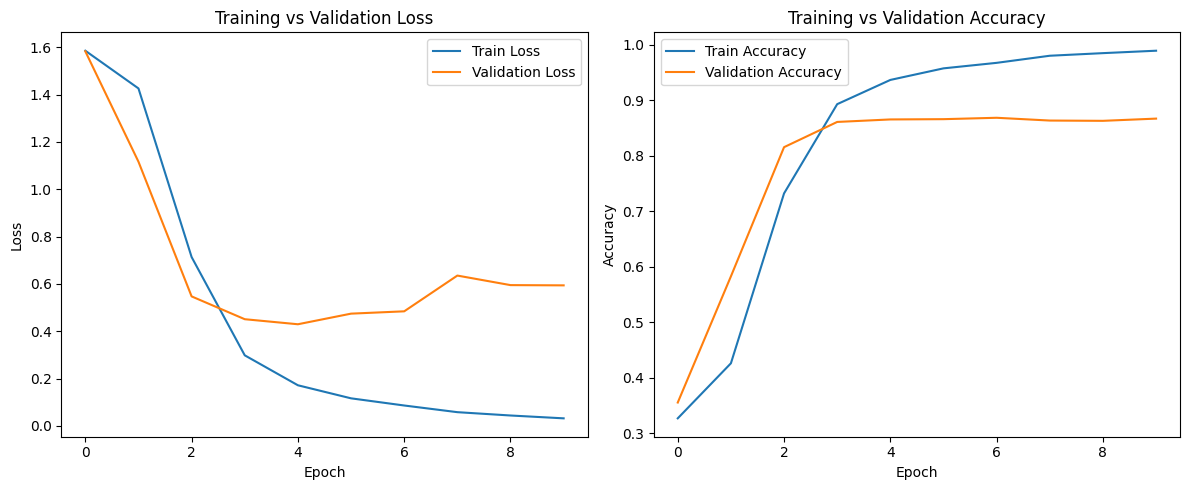

In [50]:
# ============================================
# LOSS AND ACCURACY PLOTS
# ============================================
import matplotlib.pyplot as plt
# Create figure
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(train_accuracies, label="Train Accuracy")
plt.plot(val_accuracies, label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")
plt.legend()

plt.tight_layout()
plt.show()

In [43]:
# ============================================
# FINAL TEST EVALUATION
# ============================================
test_loss, test_acc = evaluate_model(
    model,
    test_loader,
    criterion,
    device
)
print("\nFINAL TEST RESULTS")
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_acc:.4f}")


FINAL TEST RESULTS
Test Loss: 0.6047
Test Accuracy: 0.8590


In [47]:
# ============================================
# REVERSE LABEL MAPPING
# ============================================
index_to_emotion = label_map
print(index_to_emotion)

{0: 'sadness', 1: 'joy', 2: 'love', 3: 'anger', 4: 'fear', 5: 'surprise'}


### CUSTOM PREDICTIONS

In [48]:
# ============================================
# CUSTOM PREDICTION FUNCTION
# ============================================
def predict_emotion(text):

    # Set model to evaluation mode
    model.eval()
    text = clean_text(text)
    sequence = text_to_sequence(text)
    padded_sequence = pad_sequence(sequence)
    input_tensor = torch.tensor(
        [padded_sequence],
        dtype=torch.long
    ).to(device)
    with torch.no_grad():
        outputs = model(input_tensor)
        _, prediction = torch.max(outputs, dim=1)
    predicted_emotion = index_to_emotion[
        prediction.item()
    ]

    return predicted_emotion

In [49]:
# ============================================
# TEST CUSTOM SENTENCES
# ============================================

sample_1 = "I am feeling very happy today"

sample_2 = "I am scared about the exam"

sample_3 = "I miss my friends and feel lonely"

print(sample_1, "→", predict_emotion(sample_1))

print(sample_2, "→", predict_emotion(sample_2))

print(sample_3, "→", predict_emotion(sample_3))

I am feeling very happy today → joy
I am scared about the exam → fear
I miss my friends and feel lonely → sadness


### CONFUSION MATRIX

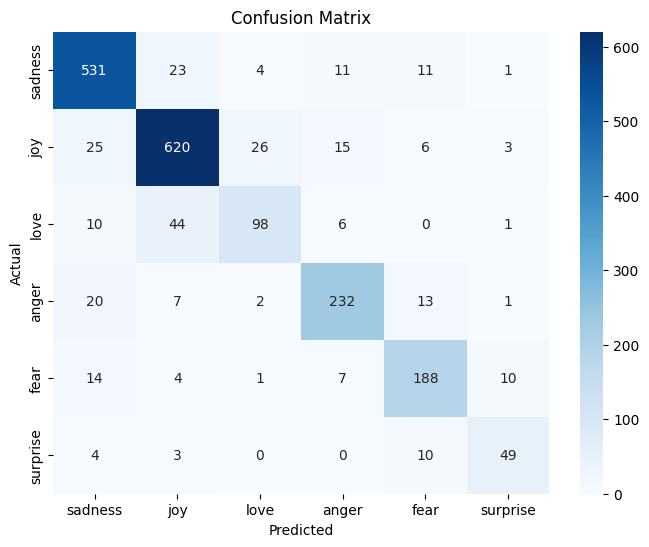

In [53]:
# ============================================
# CONFUSION MATRIX
# ============================================
from sklearn.metrics import confusion_matrix
import seaborn as sns
import numpy as np
# Store predictions
all_predictions = []
all_labels = []
model.eval()
with torch.no_grad():
    for sequences, labels in test_loader:
        sequences = sequences.to(device)
        outputs = model(sequences)
        _, predictions = torch.max(outputs, dim=1)
        all_predictions.extend(
            predictions.cpu().numpy()
        )

        all_labels.extend(labels.numpy())

# Create confusion matrix
cm = confusion_matrix(
    all_labels,
    all_predictions
)
# Plot
plt.figure(figsize=(8, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=label_map.values(),
    yticklabels=label_map.values()
)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

### CLASSIFICATION REPORT

In [54]:
# ============================================
# CLASSIFICATION REPORT
# ============================================
from sklearn.metrics import classification_report
print(
    classification_report(
        all_labels,
        all_predictions,
        target_names=label_map.values()
    )
)

              precision    recall  f1-score   support

     sadness       0.88      0.91      0.90       581
         joy       0.88      0.89      0.89       695
        love       0.75      0.62      0.68       159
       anger       0.86      0.84      0.85       275
        fear       0.82      0.84      0.83       224
    surprise       0.75      0.74      0.75        66

    accuracy                           0.86      2000
   macro avg       0.82      0.81      0.82      2000
weighted avg       0.86      0.86      0.86      2000



In [55]:
# ============================================
# SAVE TRAINED MODEL
# ============================================
torch.save(
    model.state_dict(),
    "emotion_lstm_model.pth"
)
print("Model saved successfully!")

Model saved successfully!


### BiLSTM MODEL

Bidirectional LSTM (BiLSTM)

In a standard LSTM, text is processed only from left to right.

Bidirectional LSTM improves contextual understanding by processing sequences in both directions:
- Left → Right
- Right → Left

This allows the model to capture both past and future context in a sentence, which often improves NLP performance.

In [56]:
# ============================================
# BILSTM HYPERPARAMETERS
# ============================================
BILSTM_EMBEDDING_DIM = 128
BILSTM_HIDDEN_DIM = 256
BILSTM_OUTPUT_DIM = 6
BILSTM_NUM_LAYERS = 2
BILSTM_DROPOUT = 0.3

### BiLSTM MODEL BUILDING

In [57]:
# ============================================
# BILSTM EMOTION CLASSIFIER
# ============================================
class BiLSTMEmotionClassifier(nn.Module):
    def __init__(
        self,
        vocab_size,
        embedding_dim,
        hidden_dim,
        output_dim,
        num_layers,
        dropout
    ):

        super(BiLSTMEmotionClassifier, self).__init__()
        # Embedding Layer
        self.embedding = nn.Embedding(
            num_embeddings=vocab_size,
            embedding_dim=embedding_dim,
            padding_idx=0
        )

        # BIDIRECTIONAL LSTM
        self.lstm = nn.LSTM(
            input_size=embedding_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout,
            bidirectional=True
        )

        # Dropout Layer
        self.dropout = nn.Dropout(dropout)

        # FULLY CONNECTED LAYER
        # hidden_dim * 2
        self.fc = nn.Linear(
            hidden_dim * 2,
            output_dim
        )

    def forward(self, x):
        # Embedding
        embedded = self.embedding(x)

        # BiLSTM Output
        lstm_output, (hidden, cell) = self.lstm(embedded)

        # Forward + Backward Hidden States
        forward_hidden = hidden[-2]
        backward_hidden = hidden[-1]

        # Concatenate both directions
        combined_hidden = torch.cat(
            (forward_hidden, backward_hidden),
            dim=1
        )

        # Dropout
        combined_hidden = self.dropout(
            combined_hidden
        )

        # Final Classification

        output = self.fc(combined_hidden)
        return output

In [58]:
# INITIALIZE BILSTM MODEL
bilstm_model = BiLSTMEmotionClassifier(
    vocab_size=VOCAB_SIZE,
    embedding_dim=BILSTM_EMBEDDING_DIM,
    hidden_dim=BILSTM_HIDDEN_DIM,
    output_dim=BILSTM_OUTPUT_DIM,
    num_layers=BILSTM_NUM_LAYERS,
    dropout=BILSTM_DROPOUT
)

# Move model to device
bilstm_model = bilstm_model.to(device)
print(bilstm_model)

BiLSTMEmotionClassifier(
  (embedding): Embedding(15214, 128, padding_idx=0)
  (lstm): LSTM(128, 256, num_layers=2, batch_first=True, dropout=0.3, bidirectional=True)
  (dropout): Dropout(p=0.3, inplace=False)
  (fc): Linear(in_features=512, out_features=6, bias=True)
)


In [59]:
# LOSS FUNCTION AND OPTIMIZER

bilstm_criterion = nn.CrossEntropyLoss()
bilstm_optimizer = torch.optim.Adam(
    bilstm_model.parameters(),
    lr=0.001
)

### MODEL TRAINING

In [60]:
# TRAIN BILSTM MODEL

BILSTM_EPOCHS = 10
# Metric storage
bilstm_train_losses = []
bilstm_val_losses = []
bilstm_train_accuracies = []
bilstm_val_accuracies = []

for epoch in range(BILSTM_EPOCHS):

    train_loss, train_acc = train_model(
        bilstm_model,
        train_loader,
        bilstm_criterion,
        bilstm_optimizer,
        device
    )
    # VALIDATION
    val_loss, val_acc = evaluate_model(
        bilstm_model,
        val_loader,
        bilstm_criterion,
        device
    )

    # Store metrics
    bilstm_train_losses.append(train_loss)
    bilstm_val_losses.append(val_loss)
    bilstm_train_accuracies.append(train_acc)
    bilstm_val_accuracies.append(val_acc)

    # Print results
    print(f"\nEpoch {epoch+1}/{BILSTM_EPOCHS}")
    print(f"Train Loss: {train_loss:.4f}")
    print(f"Train Accuracy: {train_acc:.4f}")
    print(f"Validation Loss: {val_loss:.4f}")
    print(f"Validation Accuracy: {val_acc:.4f}")


Epoch 1/10
Train Loss: 1.3045
Train Accuracy: 0.4992
Validation Loss: 0.8278
Validation Accuracy: 0.7045

Epoch 2/10
Train Loss: 0.5282
Train Accuracy: 0.8157
Validation Loss: 0.4034
Validation Accuracy: 0.8630

Epoch 3/10
Train Loss: 0.2812
Train Accuracy: 0.8956
Validation Loss: 0.3434
Validation Accuracy: 0.8780

Epoch 4/10
Train Loss: 0.1966
Train Accuracy: 0.9217
Validation Loss: 0.3368
Validation Accuracy: 0.8760

Epoch 5/10
Train Loss: 0.1449
Train Accuracy: 0.9414
Validation Loss: 0.3633
Validation Accuracy: 0.8785

Epoch 6/10
Train Loss: 0.1050
Train Accuracy: 0.9581
Validation Loss: 0.4512
Validation Accuracy: 0.8645

Epoch 7/10
Train Loss: 0.0742
Train Accuracy: 0.9719
Validation Loss: 0.4400
Validation Accuracy: 0.8780

Epoch 8/10
Train Loss: 0.0535
Train Accuracy: 0.9788
Validation Loss: 0.4946
Validation Accuracy: 0.8770

Epoch 9/10
Train Loss: 0.0416
Train Accuracy: 0.9851
Validation Loss: 0.5295
Validation Accuracy: 0.8740

Epoch 10/10
Train Loss: 0.0425
Train Accuracy

### MODEL EVALUATION

In [61]:
# FINAL BILSTM TEST EVALUATION

bilstm_test_loss, bilstm_test_acc = evaluate_model(
    bilstm_model,
    test_loader,
    bilstm_criterion,
    device
)

print("\nBILSTM FINAL RESULTS")
print(f"Test Loss: {bilstm_test_loss:.4f}")
print(f"Test Accuracy: {bilstm_test_acc:.4f}")


BILSTM FINAL RESULTS
Test Loss: 0.5403
Test Accuracy: 0.8665


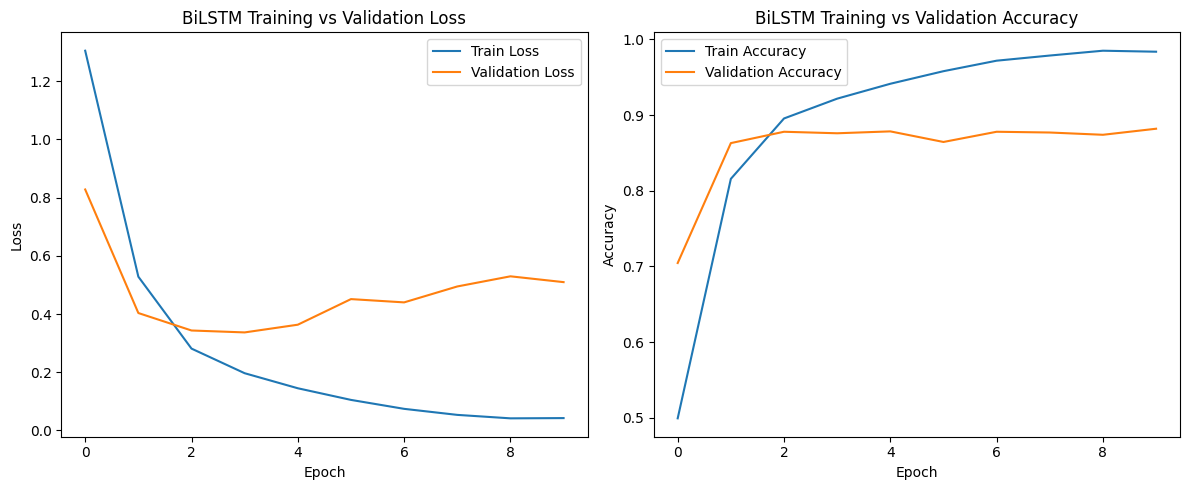

In [62]:
# BILSTM TRAINING CURVES
import matplotlib.pyplot as plt
# Create figure
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(
    bilstm_train_losses,
    label="Train Loss"
)
plt.plot(
    bilstm_val_losses,
    label="Validation Loss"
)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("BiLSTM Training vs Validation Loss")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(
    bilstm_train_accuracies,
    label="Train Accuracy"
)
plt.plot(
    bilstm_val_accuracies,
    label="Validation Accuracy"
)
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("BiLSTM Training vs Validation Accuracy")
plt.legend()

plt.tight_layout()
plt.show()

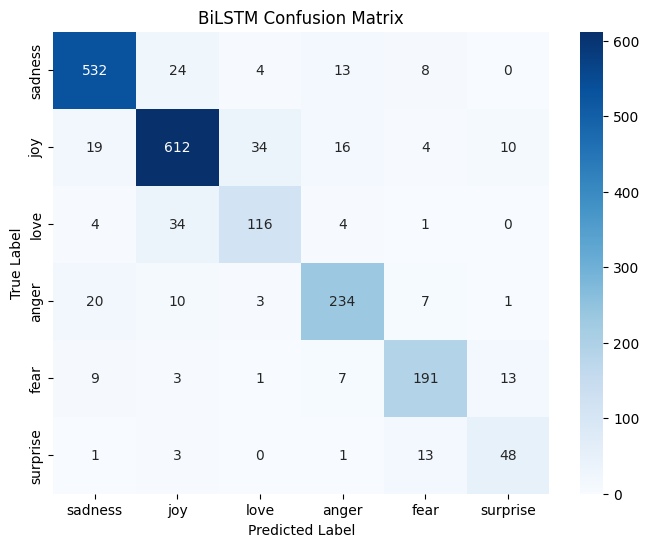

In [63]:
# BILSTM CONFUSION MATRIX

from sklearn.metrics import confusion_matrix
import seaborn as sns
import numpy as np

# Store predictions and labels
bilstm_predictions = []
bilstm_labels = []

# Evaluation mode
bilstm_model.eval()
with torch.no_grad():

    for sequences, labels in test_loader:
        sequences = sequences.to(device)
        outputs = bilstm_model(sequences)
        _, predictions = torch.max(outputs, dim=1)
        bilstm_predictions.extend(
            predictions.cpu().numpy()
        )
        bilstm_labels.extend(
            labels.numpy()
        )

# CREATE CONFUSION MATRIX
cm = confusion_matrix(
    bilstm_labels,
    bilstm_predictions
)

# PLOT CONFUSION MATRIX
plt.figure(figsize=(8, 6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=label_map.values(),
    yticklabels=label_map.values()
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("BiLSTM Confusion Matrix")
plt.show()

In [64]:
# BILSTM CLASSIFICATION REPORT

from sklearn.metrics import classification_report
print(
    classification_report(
        bilstm_labels,
        bilstm_predictions,
        target_names=label_map.values()
    )
)

              precision    recall  f1-score   support

     sadness       0.91      0.92      0.91       581
         joy       0.89      0.88      0.89       695
        love       0.73      0.73      0.73       159
       anger       0.85      0.85      0.85       275
        fear       0.85      0.85      0.85       224
    surprise       0.67      0.73      0.70        66

    accuracy                           0.87      2000
   macro avg       0.82      0.83      0.82      2000
weighted avg       0.87      0.87      0.87      2000



In [65]:
# BILSTM PREDICTION FUNCTION
def predict_emotion_bilstm(text):
    bilstm_model.eval()
    # Clean text
    text = clean_text(text)
    # Convert to sequence
    sequence = text_to_sequence(text)
    # Pad sequence
    padded_sequence = pad_sequence(sequence)
    # Tensor conversion
    input_tensor = torch.tensor(
        [padded_sequence],
        dtype=torch.long
    ).to(device)

    # Prediction
    with torch.no_grad():

        outputs = bilstm_model(input_tensor)

        _, prediction = torch.max(outputs, dim=1)

    predicted_emotion = index_to_emotion[
        prediction.item()
    ]

    return predicted_emotion

In [66]:
# TEST BILSTM PREDICTIONS
sample_1 = "I am feeling very happy today"
sample_2 = "I am scared about the exam"
sample_3 = "I miss my friends and feel lonely"
print(sample_1, "→", predict_emotion_bilstm(sample_1))
print(sample_2, "→", predict_emotion_bilstm(sample_2))
print(sample_3, "→", predict_emotion_bilstm(sample_3))

I am feeling very happy today → joy
I am scared about the exam → fear
I miss my friends and feel lonely → sadness


### MODEL COMPARISON

In [67]:
# ============================================
# MODEL COMPARISON TABLE
# ============================================
comparison_df = pd.DataFrame({

    "Model": [
        "LSTM",
        "BiLSTM"
    ],

    "Test Accuracy": [
        test_acc,
        bilstm_test_acc
    ],

    "Test Loss": [
        test_loss,
        bilstm_test_loss
    ]
})

# Convert accuracy to percentage
comparison_df["Test Accuracy"] = (
    comparison_df["Test Accuracy"] * 100
).round(2)

# Round losses
comparison_df["Test Loss"] = (
    comparison_df["Test Loss"]
).round(4)

print(comparison_df)

    Model  Test Accuracy  Test Loss
0    LSTM          85.90     0.6047
1  BiLSTM          86.65     0.5403


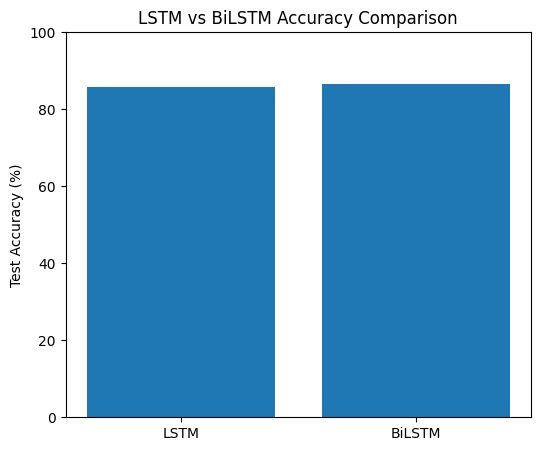

In [69]:
# ============================================
# MODEL ACCURACY COMPARISON
# ============================================
plt.figure(figsize=(6, 5))
models = ["LSTM", "BiLSTM"]
accuracies = [
    test_acc * 100,
    bilstm_test_acc * 100
]

plt.bar(models, accuracies)
plt.ylabel("Test Accuracy (%)")
plt.title("LSTM vs BiLSTM Accuracy Comparison")
plt.ylim(0, 100)
plt.show()

The Bidirectional LSTM (BiLSTM) model successfully improved the performance of the emotion classification system by learning contextual information from both forward and backward directions in a sentence.

Unlike a standard LSTM, the BiLSTM architecture processes text sequences in two directions:
- Left → Right
- Right → Left

This enables the model to better understand contextual relationships between words, leading to improved emotion recognition performance.

The BiLSTM model achieved:
- Test Accuracy: **86.65%**
- Test Loss: **0.5403**

The model showed strong performance across most emotion categories, particularly improving the classification of context-sensitive emotions such as:
- love
- sadness
- fear

The confusion matrix and classification report further demonstrated that the BiLSTM model generalized well on unseen text data while maintaining balanced precision, recall, and F1-scores across multiple classes.

Overall, this project demonstrates the effectiveness of Bidirectional LSTM networks for Natural Language Processing tasks such as text emotion classification using PyTorch without relying on transformer-based architectures.